# CNN Ablation Analysis
Validation curves and test-set metrics for each ablation axis: optimizer, learning rate, and imbalance strategy.

In [ ]:
import sys
import os
import re
import json
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, os.path.join(ROOT, 'src'))
with open(os.path.join(ROOT, 'configs', 'ablation_notebooks.json'), 'r') as f:
    NB_CFG = json.load(f)
ABLATION_CFG = NB_CFG['ablation_cnn']

from dataset import get_loaders, NUM_CLASSES, CLASS_NAMES

def load_module(name, filepath):
    spec = importlib.util.spec_from_file_location(name, filepath)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

cnn_mod = load_module('custom_cnn', os.path.join(ROOT, ABLATION_CFG['module_path']))
custom_CNN = cnn_mod.custom_CNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ABLATION_ROOT = os.path.join(ROOT, ABLATION_CFG['ablation_root'])
print(f'Device: {device}')

Device: cuda


In [2]:
_, _, test_loader = get_loaders()
print(f'Test batches: {len(test_loader)}')

Test batches: 32


In [3]:
def parse_training_log(log_path):
    history = {'val_loss': [], 'val_acc': []}
    pattern = re.compile(
        r'val_loss=([\d.]+)\s+val_acc=([\d.]+)%'
    )
    with open(log_path) as f:
        for line in f:
            m = pattern.search(line)
            if m:
                history['val_loss'].append(float(m.group(1)))
                history['val_acc'].append(float(m.group(2)))
    return history

def get_predictions(model, loader, device):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def compute_metrics(pth_path):
    model = custom_CNN(num_classes=NUM_CLASSES)
    model.load_state_dict(torch.load(pth_path, map_location=device))
    model.to(device).eval()
    labels, preds, probs = get_predictions(model, test_loader, device)
    label_matrix = np.eye(NUM_CLASSES)[labels]
    return {
        'accuracy':      (preds == labels).mean() * 100,
        'macro_auc':     roc_auc_score(label_matrix, probs, average='macro', multi_class='ovr'),
        'micro_auc':     roc_auc_score(label_matrix, probs, average='micro', multi_class='ovr'),
        'per_class_auc': roc_auc_score(label_matrix, probs, average=None,   multi_class='ovr'),
        'report':        classification_report(labels, preds, target_names=CLASS_NAMES, zero_division=0),
    }

def plot_val_curves(runs, title):
    """runs: dict of {label: history}"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, h in runs.items():
        epochs = range(1, len(h['val_loss']) + 1)
        axes[0].plot(epochs, h['val_loss'], label=name)
        axes[1].plot(epochs, h['val_acc'],  label=name)
    for ax, ylabel in zip(axes, ['Val Loss', 'Val Accuracy (%)']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{title} — {ylabel}')
        ax.legend()
        ax.grid(True)
    plt.tight_layout()
    plt.show()

def print_metrics_table(metrics_dict):
    print(f"{'Run':<30}  {'Accuracy':>10}  {'Macro AUC':>10}  {'Micro AUC':>10}")
    print('-' * 68)
    for name, m in metrics_dict.items():
        print(f"{name:<30}  {m['accuracy']:>9.2f}%  {m['macro_auc']:>10.4f}  {m['micro_auc']:>10.4f}")
    print(f"\nPer-class AUC")
    print(f"{'Class':<25}", end='')
    for name in metrics_dict:
        print(f"  {name:>12}", end='')
    print()
    print('-' * (25 + 14 * len(metrics_dict)))
    for i, cls in enumerate(CLASS_NAMES):
        print(f"{cls:<25}", end='')
        for m in metrics_dict.values():
            print(f"  {m['per_class_auc'][i]:>12.4f}", end='')
        print()

def print_classification_reports(metrics_dict):
    for name, m in metrics_dict.items():
        print(f'\n--- {name} ---')
        print(m['report'])

---
## Axis 1: Optimizer
Fixed: `lr=1e-3`, `imbalance=none`

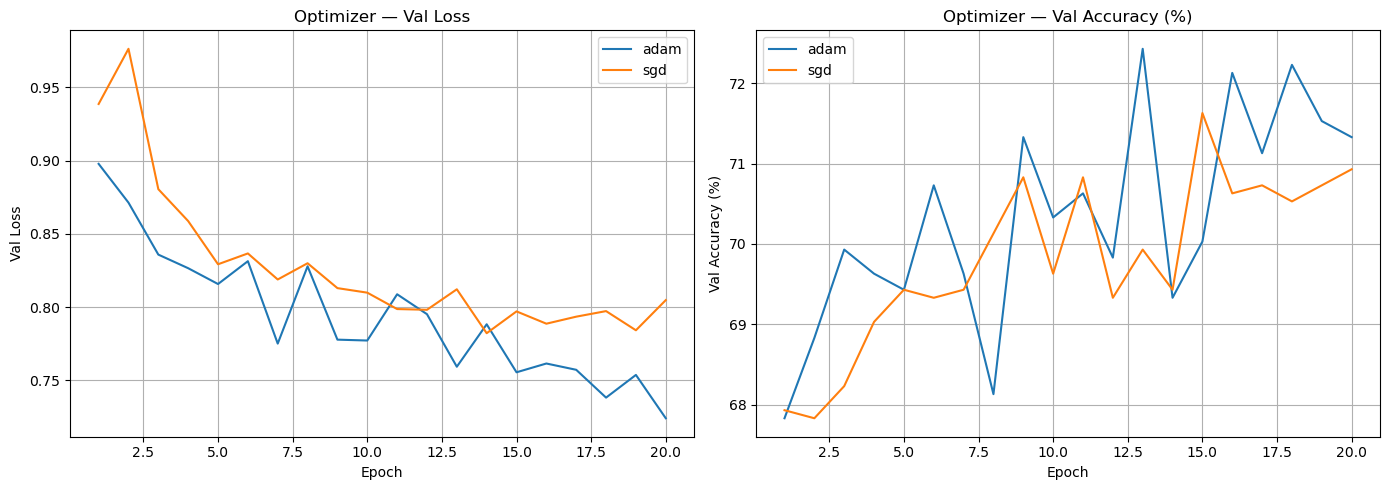

In [4]:
opt_runs = {
    'adam': parse_training_log(os.path.join(ABLATION_ROOT, 'optimizer', 'adam', 'training_log.txt')),
    'sgd':  parse_training_log(os.path.join(ABLATION_ROOT, 'optimizer', 'sgd',  'training_log.txt')),
}
plot_val_curves(opt_runs, 'Optimizer')

In [5]:
opt_pths = {
    'adam': os.path.join(ABLATION_ROOT, 'optimizer', 'adam', 'adam_lr0.001_none.pth'),
    'sgd':  os.path.join(ABLATION_ROOT, 'optimizer', 'sgd',  'sgd_lr0.001_none.pth'),
}
opt_metrics = {}
for name, path in opt_pths.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    opt_metrics[name] = compute_metrics(path)
    print('done')

print_metrics_table(opt_metrics)

Evaluating adam... done
Evaluating sgd... done
Run                               Accuracy   Macro AUC   Micro AUC
--------------------------------------------------------------------
adam                                71.86%      0.8933      0.9556
sgd                                 71.06%      0.8791      0.9471

Per-class AUC
Class                              adam           sgd
-----------------------------------------------------
MEL                              0.8641        0.8519
NV                               0.8942        0.8814
BCC                              0.9322        0.9157
AKIEC                            0.9154        0.9036
BKL                              0.8416        0.8061
DF                               0.8142        0.8386
VASC                             0.9910        0.9562


In [6]:
print_classification_reports(opt_metrics)


--- adam ---
              precision    recall  f1-score   support

         MEL       0.57      0.29      0.38       112
          NV       0.77      0.96      0.85       671
         BCC       0.35      0.31      0.33        52
       AKIEC       0.40      0.06      0.11        32
         BKL       0.45      0.23      0.30       110
          DF       0.00      0.00      0.00        11
        VASC       1.00      0.21      0.35        14

    accuracy                           0.72      1002
   macro avg       0.50      0.29      0.33      1002
weighted avg       0.67      0.72      0.67      1002


--- sgd ---
              precision    recall  f1-score   support

         MEL       0.50      0.23      0.32       112
          NV       0.78      0.94      0.86       671
         BCC       0.39      0.21      0.28        52
       AKIEC       0.30      0.28      0.29        32
         BKL       0.40      0.30      0.34       110
          DF       0.00      0.00      0.00        

---
## Axis 2: Learning Rate
Fixed: best optimizer from Axis 1, `imbalance=none`

Best optimizer: adam


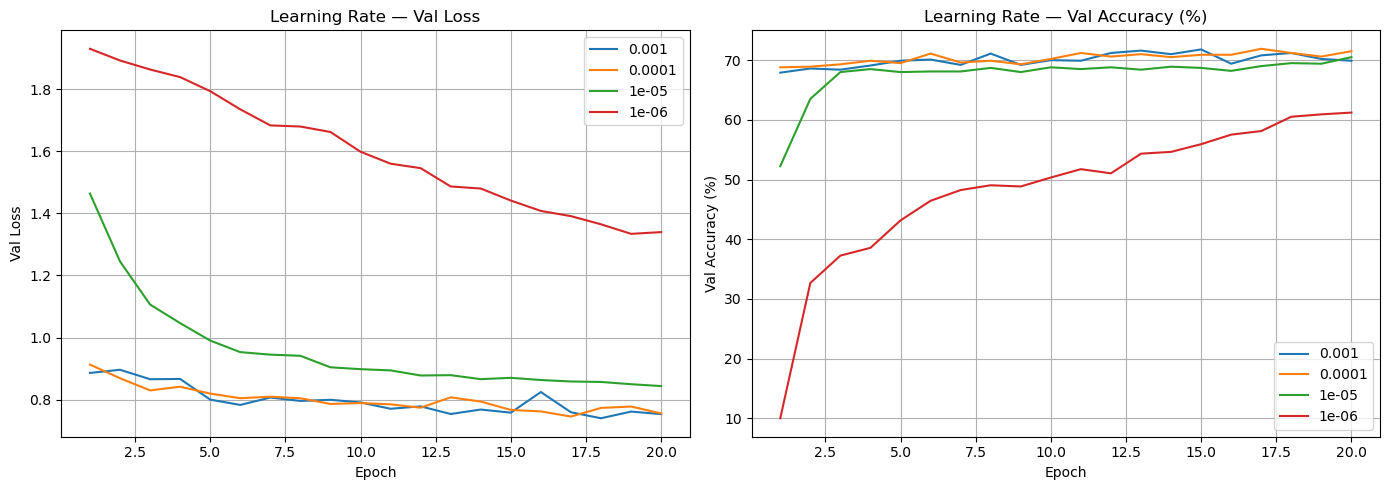

In [7]:
LR_VALUES = ['0.001', '0.0001', '1e-05', '1e-06']

# Read best optimizer from summary.json
with open(os.path.join(ABLATION_ROOT, 'summary.json')) as f:
    summary = json.load(f)
best_opt = summary['best_config']['optimizer']
print(f'Best optimizer: {best_opt}')

lr_runs = {
    lr: parse_training_log(os.path.join(ABLATION_ROOT, 'lr', lr, 'training_log.txt'))
    for lr in LR_VALUES
}
plot_val_curves(lr_runs, 'Learning Rate')

In [8]:
lr_pths = {
    lr: os.path.join(ABLATION_ROOT, 'lr', lr, f'{best_opt}_lr{lr}_none.pth')
    for lr in LR_VALUES
}
lr_metrics = {}
for name, path in lr_pths.items():
    print(f'Evaluating lr={name}...', end=' ', flush=True)
    lr_metrics[name] = compute_metrics(path)
    print('done')

print_metrics_table(lr_metrics)

Evaluating lr=0.001... done
Evaluating lr=0.0001... done
Evaluating lr=1e-05... done
Evaluating lr=1e-06... done
Run                               Accuracy   Macro AUC   Micro AUC
--------------------------------------------------------------------
0.001                               71.66%      0.8848      0.9531
0.0001                              72.06%      0.8882      0.9527
1e-05                               68.76%      0.8681      0.9428
1e-06                               60.28%      0.7136      0.8949

Per-class AUC
Class                             0.001        0.0001         1e-05         1e-06
---------------------------------------------------------------------------------
MEL                              0.8608        0.8651        0.8631        0.8040
NV                               0.8903        0.8894        0.8610        0.7412
BCC                              0.9384        0.9263        0.8885        0.8111
AKIEC                            0.9060        0.9148     

In [9]:
print_classification_reports(lr_metrics)


--- 0.001 ---
              precision    recall  f1-score   support

         MEL       0.43      0.44      0.43       112
          NV       0.80      0.92      0.86       671
         BCC       0.47      0.15      0.23        52
       AKIEC       0.45      0.28      0.35        32
         BKL       0.43      0.33      0.37       110
          DF       0.00      0.00      0.00        11
        VASC       1.00      0.07      0.13        14

    accuracy                           0.72      1002
   macro avg       0.51      0.31      0.34      1002
weighted avg       0.69      0.72      0.69      1002


--- 0.0001 ---
              precision    recall  f1-score   support

         MEL       0.47      0.34      0.40       112
          NV       0.79      0.94      0.86       671
         BCC       0.44      0.21      0.29        52
       AKIEC       0.43      0.38      0.40        32
         BKL       0.46      0.28      0.35       110
          DF       0.00      0.00      0.00    

---
## Axis 3: Imbalance Strategy
Fixed: best optimizer + best LR from Axes 1 & 2

Best optimizer: adam | Best LR: 0.0001


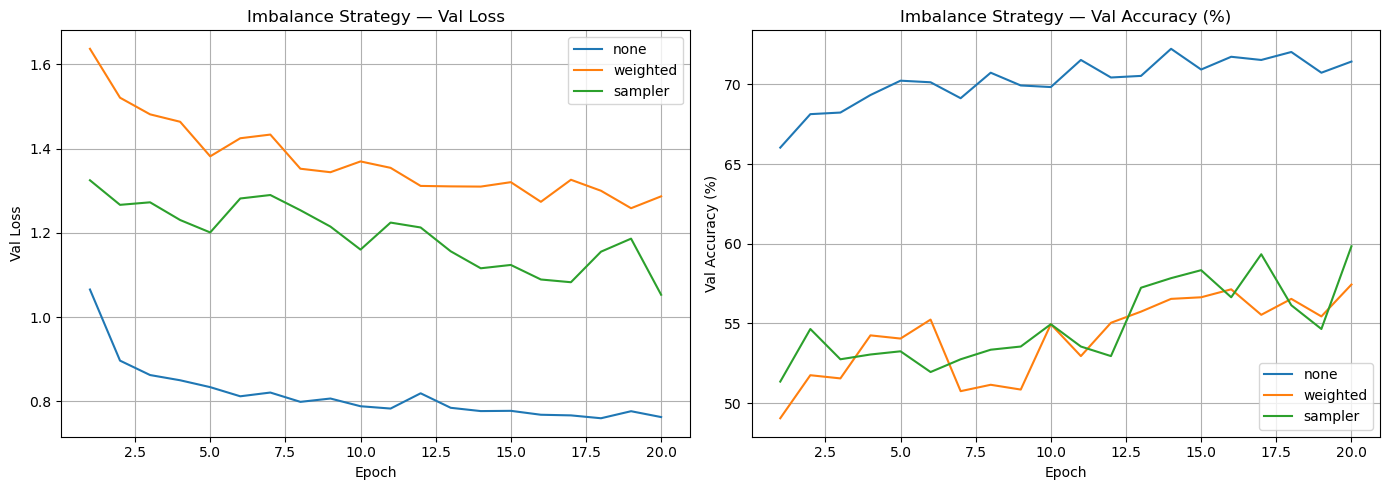

In [10]:
best_lr  = str(summary['best_config']['lr'])
print(f'Best optimizer: {best_opt} | Best LR: {best_lr}')

IMB_VALUES = ['none', 'weighted', 'sampler']
imb_runs = {
    imb: parse_training_log(os.path.join(ABLATION_ROOT, 'imbalance', imb, 'training_log.txt'))
    for imb in IMB_VALUES
}
plot_val_curves(imb_runs, 'Imbalance Strategy')

In [11]:
imb_pths = {
    imb: os.path.join(ABLATION_ROOT, 'imbalance', imb, f'{best_opt}_lr{best_lr}_{imb}.pth')
    for imb in IMB_VALUES
}
imb_metrics = {}
for name, path in imb_pths.items():
    print(f'Evaluating {name}...', end=' ', flush=True)
    imb_metrics[name] = compute_metrics(path)
    print('done')

print_metrics_table(imb_metrics)

Evaluating none... done
Evaluating weighted... done
Evaluating sampler... done
Run                               Accuracy   Macro AUC   Micro AUC
--------------------------------------------------------------------
none                                71.86%      0.8907      0.9518
weighted                            58.48%      0.8619      0.8870
sampler                             59.18%      0.8842      0.9018

Per-class AUC
Class                              none      weighted       sampler
-------------------------------------------------------------------
MEL                              0.8728        0.8382        0.8551
NV                               0.8868        0.8733        0.8760
BCC                              0.9262        0.9099        0.9416
AKIEC                            0.9059        0.8968        0.9096
BKL                              0.8260        0.7586        0.7822
DF                               0.8323        0.7750        0.8351
VASC                     

In [12]:
print_classification_reports(imb_metrics)


--- none ---
              precision    recall  f1-score   support

         MEL       0.45      0.39      0.42       112
          NV       0.79      0.94      0.86       671
         BCC       0.47      0.13      0.21        52
       AKIEC       0.41      0.28      0.33        32
         BKL       0.45      0.27      0.34       110
          DF       0.00      0.00      0.00        11
        VASC       0.00      0.00      0.00        14

    accuracy                           0.72      1002
   macro avg       0.37      0.29      0.31      1002
weighted avg       0.66      0.72      0.68      1002


--- weighted ---
              precision    recall  f1-score   support

         MEL       0.34      0.55      0.42       112
          NV       0.94      0.66      0.78       671
         BCC       0.28      0.46      0.35        52
       AKIEC       0.19      0.62      0.29        32
         BKL       0.30      0.20      0.24       110
          DF       0.08      0.27      0.12   

---
## Best Config Summary

In [13]:
print(json.dumps(summary['best_config'], indent=2))

{
  "optimizer": "adam",
  "lr": 0.0001,
  "imbalance": "none"
}
